# Predicting Web Traffic Patterns with Time Series Analysis
Website Traffic Forecasting involves predicting web traffic patterns over specific time periods. This represents one of the most practical applications of Time Series Forecasting techniques. For those interested in learning how to predict website visitor patterns, this tutorial provides a comprehensive guide. Throughout this project, I will walk you through the complete process of Website Traffic Forecasting using Python.

<div align="center">
<img src="https://www.thesoulwithin.com/wp-content/uploads/2023/02/website-traffic.png" />
</div>

## Website Traffic Forecasting using Python
The dataset utilized for this Website Traffic Forecasting project is sourced from the daily visitor statistics of thecleverprogrammer.com. This dataset encompasses daily web traffic information spanning from June 2021 to June 2022. The dataset is available for download from the provided link. Let's begin our website traffic forecasting journey by importing the required Python libraries and loading the dataset, which you can obtain from [here](https://statso.io/forecasting-website-traffic-case-study/).

## 1. Importing Libraries
First, we will import the necessary Python libraries to perform the website traffic forecasting task. These libraries will help us load the dataset, visualize the data, and implement the forecasting models.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

import warnings

### Configuration
Let's configure the necessary settings.

In [2]:
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style('darkgrid')

## 2. Data Loading
Next, we will load the dataset into a pandas DataFrame and take a quick look at its structure.

In [3]:
df = pd.read_csv('Thecleverprogrammer.csv')

In [4]:
df.head()

,Date,Views
0,01/06/2021,7831
1,02/06/2021,7798
2,03/06/2021,7401
3,04/06/2021,7054
4,05/06/2021,7973


In [5]:
df.shape

(391, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391 entries, 0 to 390
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    391 non-null    object
 1   Views   391 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 6.2+ KB


## 3. Data Visualization
Next, we will visualize the data to understand it better.

In [7]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

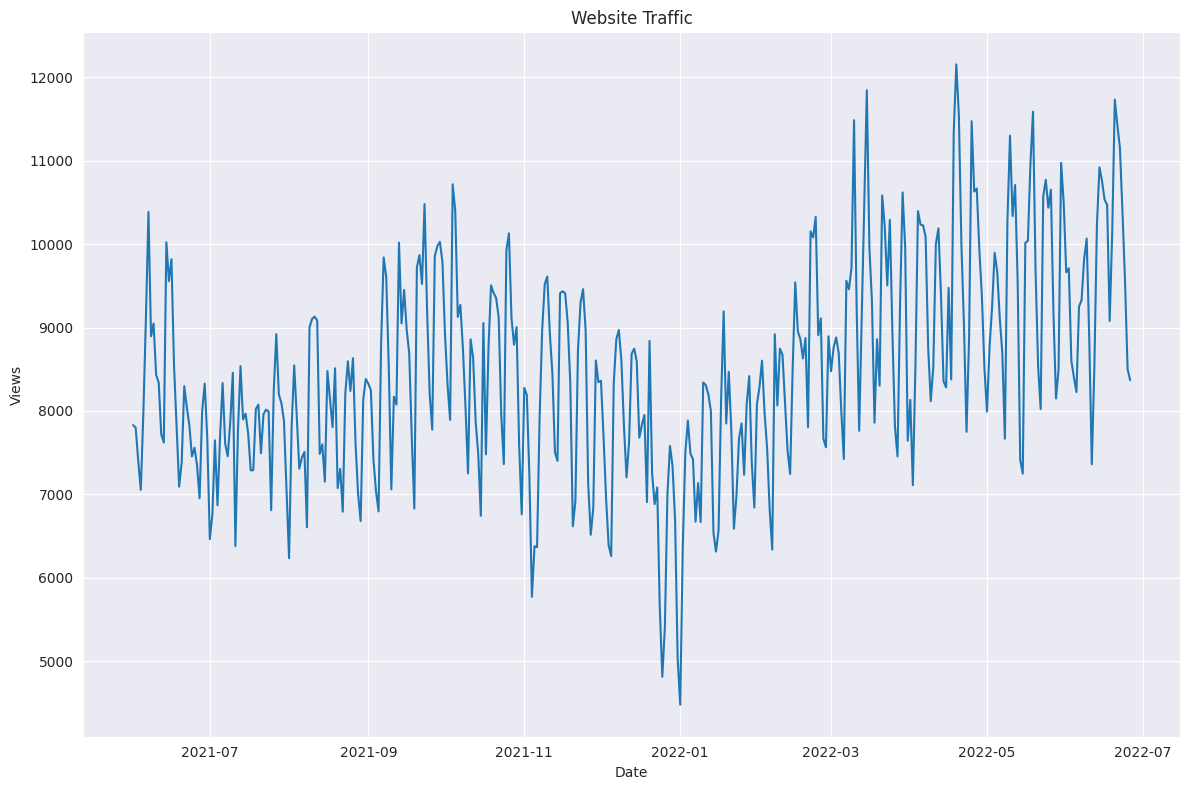

In [8]:
sns.lineplot(df, x='Date', y='Views')
plt.title('Website Traffic')
plt.tight_layout()

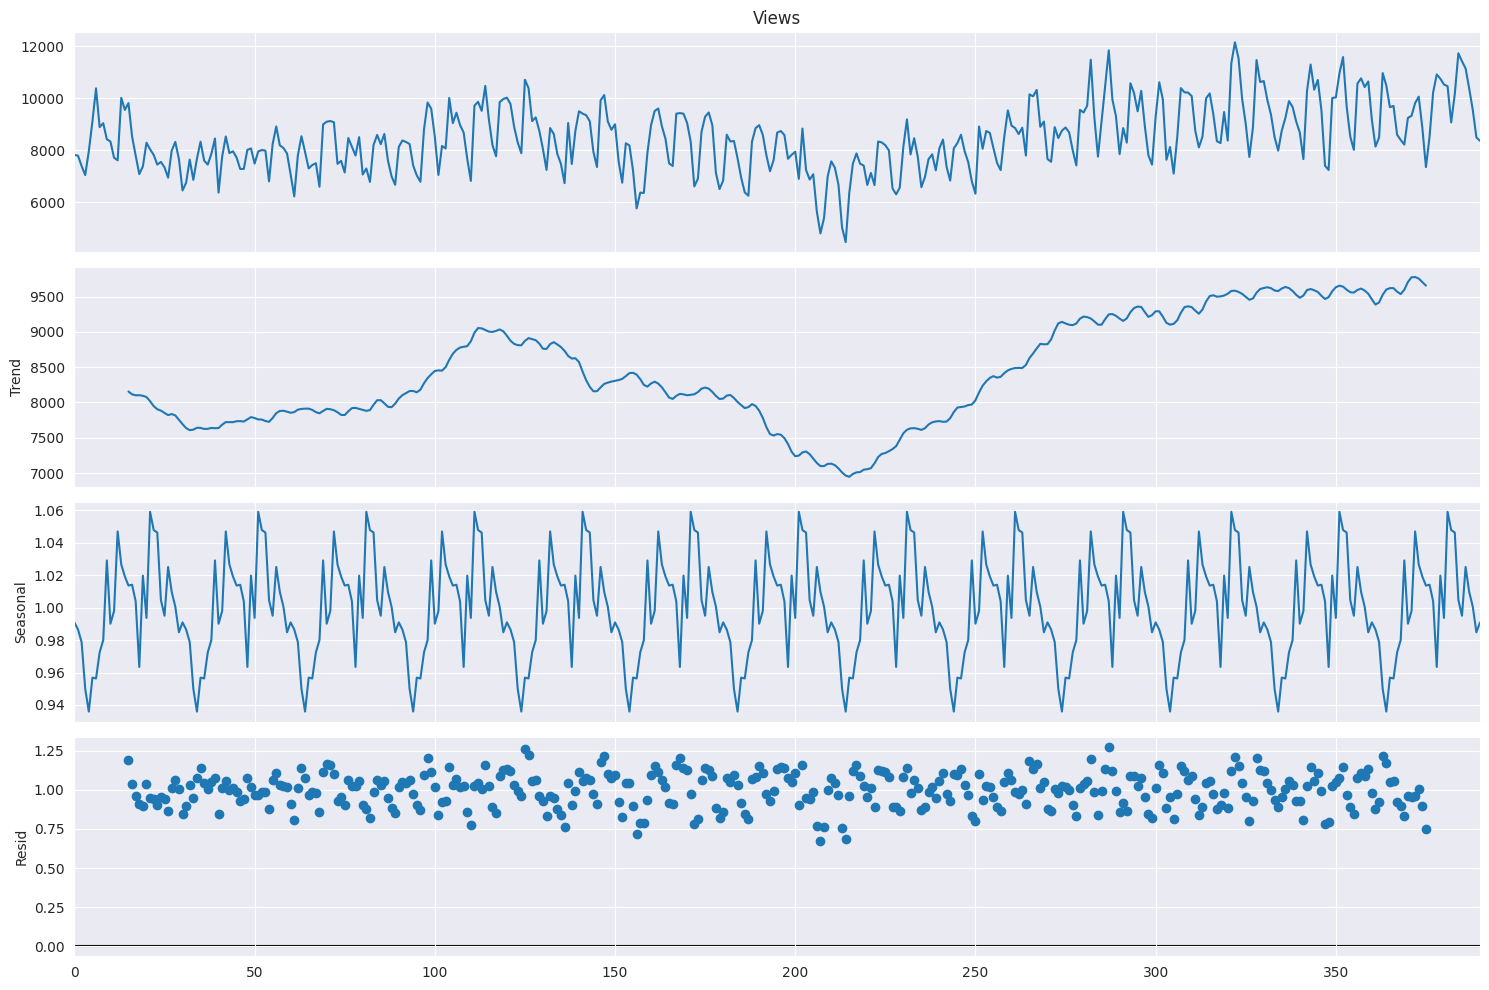

In [12]:
result = seasonal_decompose(df['Views'], model='multiplicative', period=30)

fig = result.plot()
fig.set_size_inches(15, 10)
plt.tight_layout()

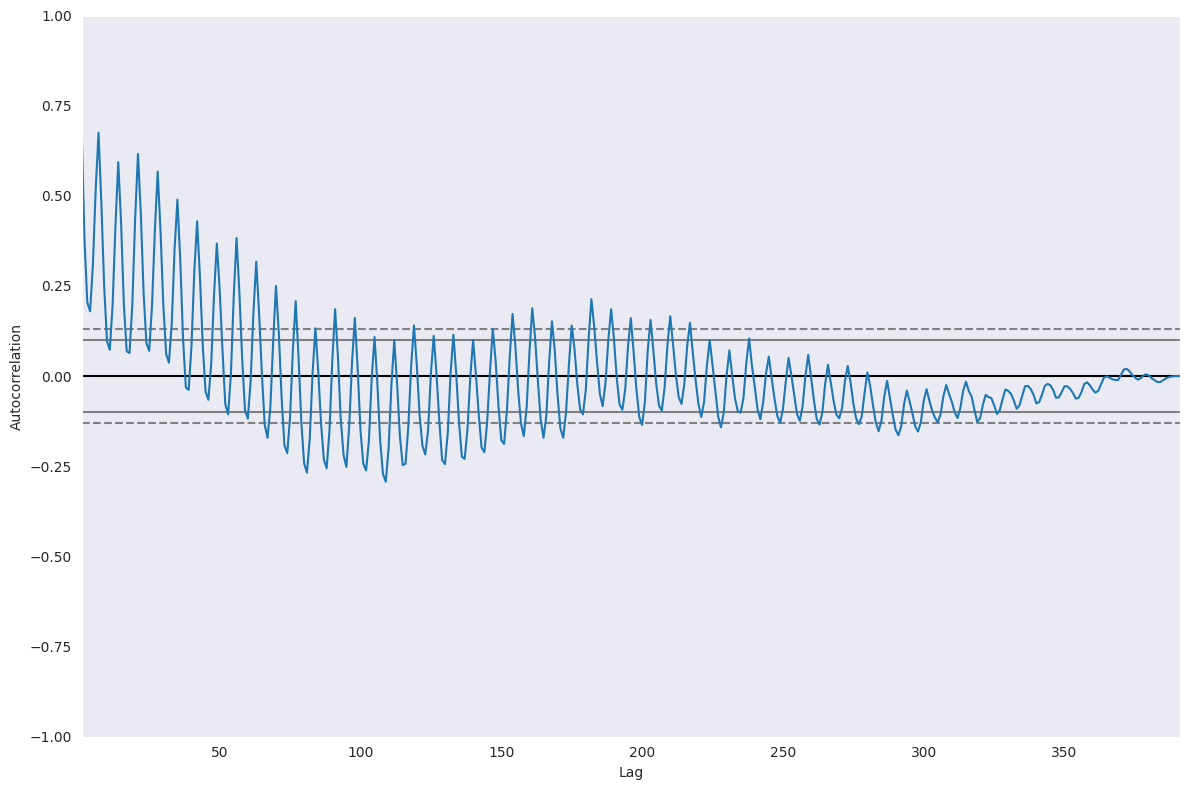

In [15]:
pd.plotting.autocorrelation_plot(df['Views'])
plt.tight_layout()

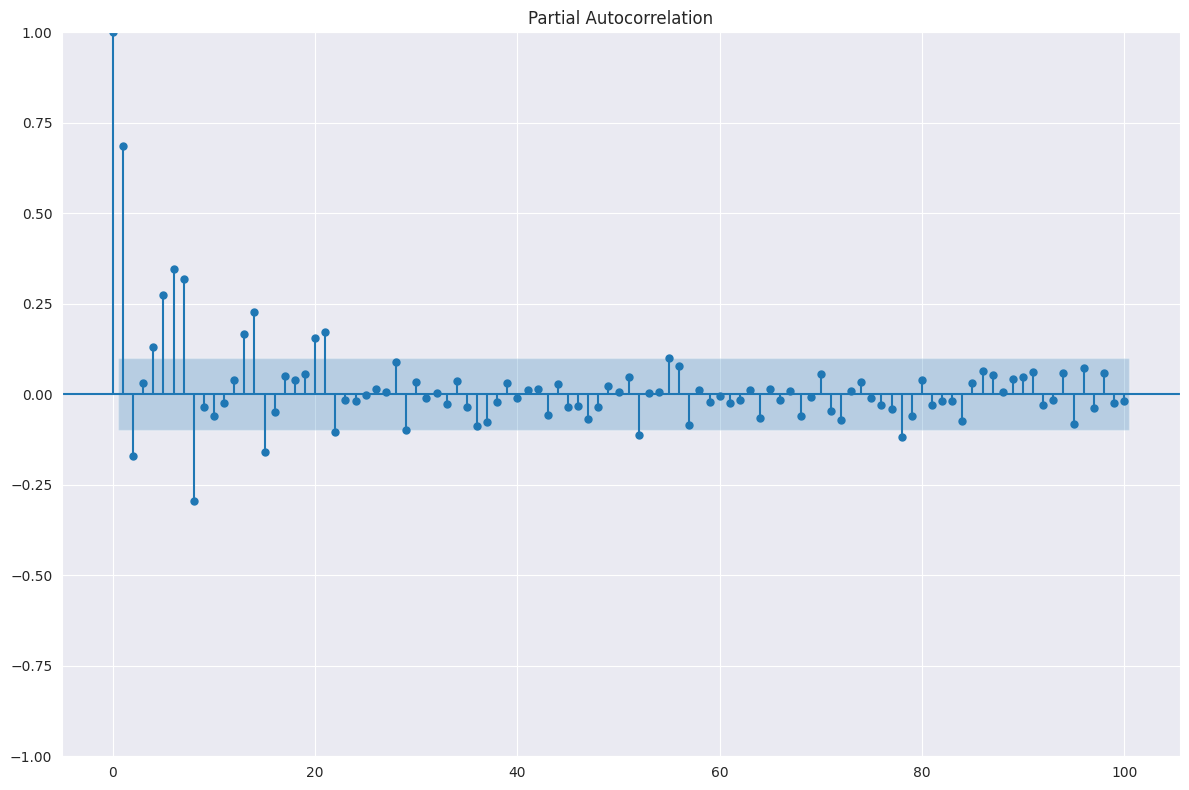

In [13]:
plot_pacf(df['Views'], lags=100)
plt.tight_layout()

## 4. Model Building
Next, we will build the model to predict the website traffic. I will be using the Seasonal ARIMA (SARIMA) model for this. Before building the model, we need to find the best parameters for the model. They are `p`, `d`, and `q` values.

- `p`: The number of lagged values that need to be added or subtracted from the values (label column). It captures the autoregressive part of ARIMA.
- `d`: Represents the number of times the data needs to differentiate to produce a stationary signal. If it’s stationary data, the value of d should be 0, and if it’s seasonal data, the value of d should be 1. d captures the integrated part of ARIMA.
- `q`: The number of lagged values for the error term added or subtracted from the values (label column). It captures the moving average part of ARIMA.

For `d`, the data is non-stationary, so the value of d should be 1. 

To find the values for `p` and `q`, we plot the autocorrelation plot and partial autocorrelation plot. Best value for `p` is 5 and best value for `q` is 2.

In [16]:
p, d, q = 5, 1, 2

In [18]:
model = SARIMAX(df['Views'], order=(p, d, q), seasonal_order=(p, d, q, 12))
model = model.fit()

In [19]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              Views   No. Observations:                  391
Model:             SARIMAX(5, 1, 2)x(5, 1, 2, 12)   Log Likelihood               -3098.842
Date:                            Sun, 28 Sep 2025   AIC                           6227.683
Time:                                    15:33:24   BIC                           6286.707
Sample:                                         0   HQIC                          6251.109
                                            - 391                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7750      0.130      5.967      0.000       0.520       1.030
ar.L2         -0.7901      0.136     -5.816      0.000      -1.056      -0.524
ar.L3         -0.1338      0.172     -0.777      0.437      -0.471       0.204
ar.L4         -0.2055      0.153     -1.344      0.179      -0.505       0.094
ar.L5         -0.1367      0.137     -1.000      0.317      -0.405       0.131
ma.L1         -1.1866      0.085    -13.996      0.000      -1.353      -1.020
ma.L2          0.9012      0.072     12.472      0.000       0.760       1.043
ar.S.L12      -0.2373      4.356     -0.054      0.957      -8.775       8.301
ar.S.L24       0.0615      0.552      0.111      0.911      -1.021       1.144
ar.S.L36      -0.1760      0.296     -0.595      0.552      -0.756       0.404
ar.S.L48      -0.2075      0.863     -0.240      0.810      -1.898       1.483
ar.S.L60       0.0116      0.888      0.013      0.990      -1.729       1.752
ma.S.L12      -0.6993      4.357     -0.161      0.872      -9.239       7.840
ma.S.L24      -0.1186      3.570     -0.033      0.973      -7.115       6.878
sigma2      1.257e+06   1.72e-05   7.31e+10      0.000    1.26e+06    1.26e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 1.09
Prob(Q):                              0.89   Prob(JB):                         0.58
Heteroskedasticity (H):               1.06   Skew:                             0.13
Prob(H) (two-sided):                  0.76   Kurtosis:                         2.99
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 5.49e+27. Standard errors may be unstable.
"""

Now, let's make predictions for the next 60 days.

In [20]:
predictions = model.predict(len(df), len(df) + 60)
predictions

391     9887.389545
392    10792.582774
393    10722.422896
394     9849.300095
395     8790.321474
           ...     
447    10317.900390
448    11071.953257
449    10766.504076
450    10377.932445
451     9579.079835
Name: predicted_mean, Length: 61, dtype: float64

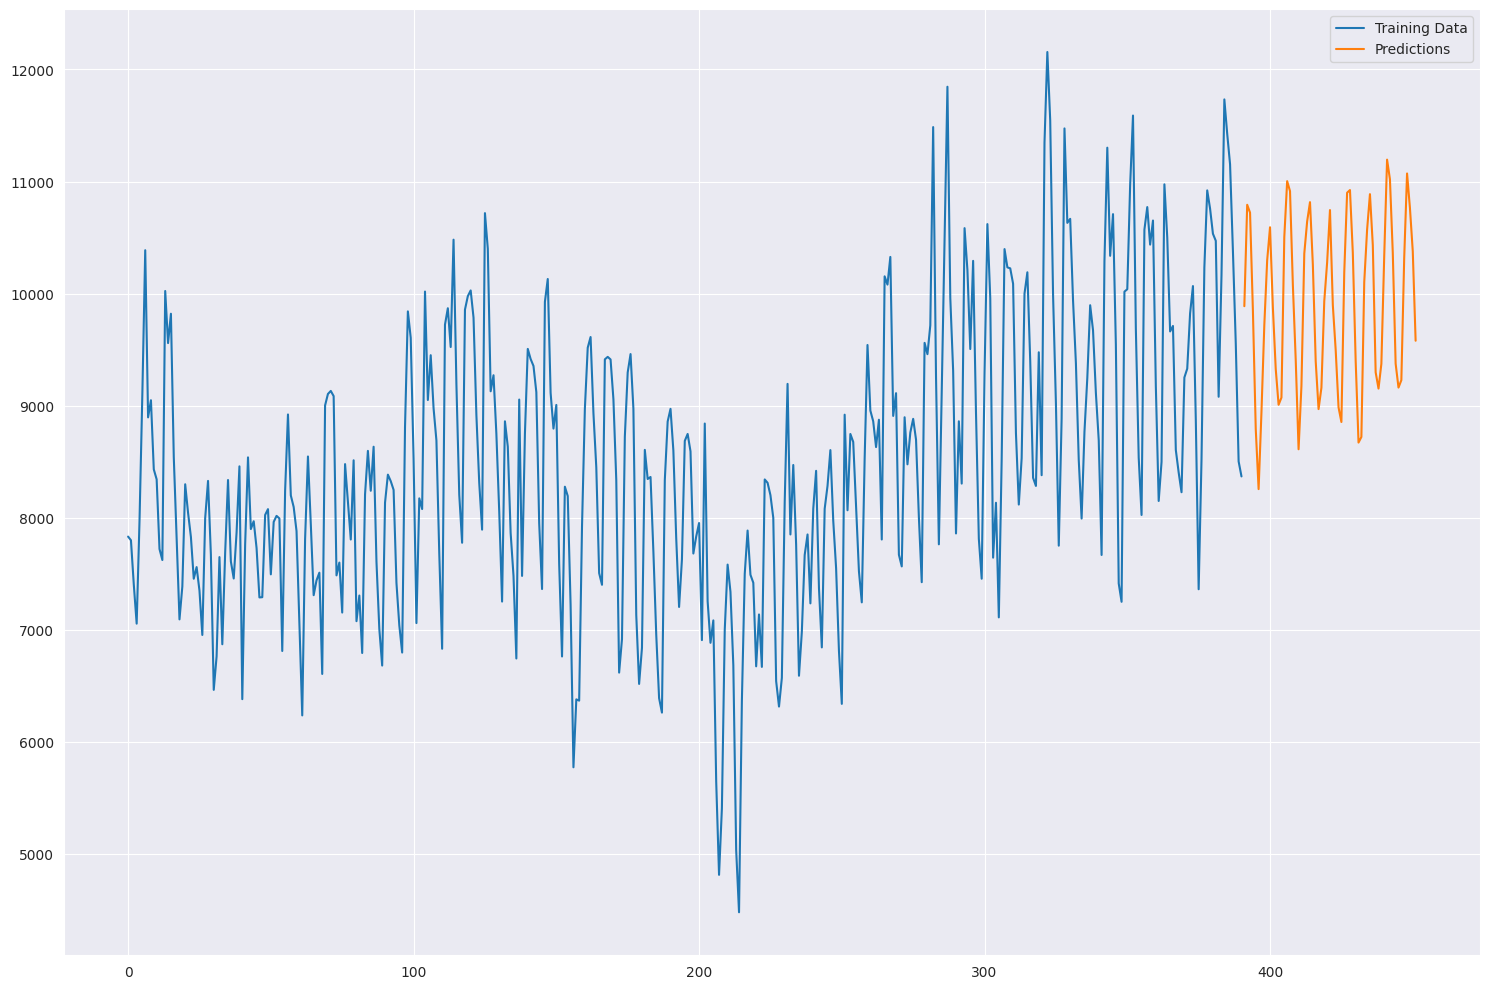

In [21]:
df['Views'].plot(legend=True, label='Training Data', figsize=(15, 10))
predictions.plot(legend=True, label='Predictions')
plt.tight_layout()

Let's save the model.

In [22]:
model.save('website_traffic_model.pkl')

## 5. Conclusion

This project successfully demonstrates the application of time series forecasting techniques to predict website traffic patterns. Using a SARIMA model with parameters (5,1,2) and seasonal order (5,1,2,12), we were able to analyze daily visitor data from thecleverprogrammer.com spanning June 2021 to June 2022.

### Key Insights:
- The website traffic data exhibits clear seasonal patterns and trends
- The multiplicative seasonal decomposition revealed underlying patterns in the data
- The SARIMA model effectively captured both autoregressive and seasonal components
- The model can generate 60-day ahead forecasts for traffic planning

### Future Improvements:
- **Feature Engineering**: Incorporate external factors like marketing campaigns, holidays, or content publication schedules
- **Model Comparison**: Test other models like LSTM, Prophet, or XGBoost for performance comparison
- **Hyperparameter Tuning**: Implement automated parameter optimization using grid search or Bayesian optimization
- **Real-time Updates**: Implement model retraining with new data to maintain accuracy
- **Confidence Intervals**: Add prediction intervals to quantify forecast uncertainty
- **Validation**: Implement proper train/validation/test splits and cross-validation for robust evaluation